In [8]:
# === Imports (une seule cellule, organisés, sans tests) ===

# Bibliothèques standard
import os
import sys
import json
import zipfile
import random
import shutil
from datetime import datetime
from pathlib import Path

# Scientific / utils
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import requests

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import data as tf_data
import keras

# MLflow
import mlflow
import mlflow.keras
from mlflow import MlflowClient
from mlflow.models.signature import infer_signature, ModelSignature
from mlflow.types import Schema, ColSpec, TensorSpec


In [9]:
import tensorflow as tf, subprocess

# 1) Ce que voit TensorFlow (GPU Metal)
print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("TF GPUs:", gpus)
for d in gpus:
    print("TF GPU details:", tf.config.experimental.get_device_details(d))

# 2) Modèle exact côté macOS (system_profiler)
out = subprocess.run(
    ["system_profiler", "SPDisplaysDataType"],
    capture_output=True, text=True
).stdout
for line in out.splitlines():
    if ("Chipset Model:" in line) or ("VRAM" in line) or ("Metal" in line):
        print(line.strip())


TensorFlow: 2.16.2
TF GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF GPU details: {'device_name': 'METAL'}
Chipset Model: Apple M4
Metal Support: Metal 3


In [18]:
from pathlib import Path

# Racine de tes données (suivant ta capture)
ROOT_CS = Path("/Users/anasesseddiki/Desktop/Projet8/data")

# Chemins exacts (avec le niveau P8_Cityscapes_*)
IMG_DIR = ROOT_CS / "P8_Cityscapes_leftImg8bit_trainvaltest" / "leftImg8bit"
GT_DIR  = ROOT_CS / "P8_Cityscapes_gtFine_trainvaltest"      / "gtFine"

# Comptages rapides
def count_pngs(d: Path, pattern: str) -> int:
    return len(list(d.rglob(pattern))) if d.exists() else 0

splits = ["train", "val", "test"]
counts = {
    s: {
        "images":      count_pngs(IMG_DIR / s, "*_leftImg8bit.png"),
        "gt_trainIds": count_pngs(GT_DIR  / s, "*_gtFine_trainIds.png"),
        "gt_labelIds": count_pngs(GT_DIR  / s, "*_gtFine_labelIds.png"),
        "gt_color":    count_pngs(GT_DIR  / s, "*_gtFine_color.png"),
    }
    for s in splits
}

print("📁 Images :", IMG_DIR)
print("📁 Masks  :", GT_DIR)
print("\n📊 Comptes par split:")
for s in splits:
    c = counts[s]
    print(f"  - {s:5s} | images={c['images']:4d} | trainIds={c['gt_trainIds']:4d} | labelIds={c['gt_labelIds']:4d} | color={c['gt_color']:4d}")


📁 Images : /Users/anasesseddiki/Desktop/Projet8/data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit
📁 Masks  : /Users/anasesseddiki/Desktop/Projet8/data/P8_Cityscapes_gtFine_trainvaltest/gtFine

📊 Comptes par split:
  - train | images=2975 | trainIds=   0 | labelIds=2975 | color=2975
  - val   | images= 500 | trainIds=   0 | labelIds= 500 | color= 500
  - test  | images=1525 | trainIds=   0 | labelIds=1525 | color=1525


In [19]:
from pathlib import Path
import numpy as np
from PIL import Image
from tqdm import tqdm

# Dossier gtFine exact (suivant ton arborescence)
GT_DIR = Path("/Users/anasesseddiki/Desktop/Projet8/data/P8_Cityscapes_gtFine_trainvaltest/gtFine")

# LUT officielle Cityscapes : labelId -> trainId (255 = ignore)
LABELID_TO_TRAINID = {
     0:255,  1:255,  2:255,  3:255,  4:255,  5:255,  6:255,  # unlabeled...ground
     7:0,    8:1,                                            # road, sidewalk
     9:255, 10:255,                                          # parking, rail track (ignored)
    11:2,   12:3,   13:4,                                    # building, wall, fence
    14:255, 15:255, 16:255,                                  # guard rail, bridge, tunnel (ignored)
    17:5,   18:255,                                          # pole, polegroup (ignored)
    19:6,   20:7,                                            # traffic light, traffic sign
    21:8,   22:9,   23:10,                                   # vegetation, terrain, sky
    24:11,  25:12,                                           # person, rider
    26:13,  27:14,  28:15,                                   # car, truck, bus
    29:255, 30:255,                                          # caravan, trailer (ignored)
    31:16,  32:17,  33:18,                                   # train, motorcycle, bicycle
    34:255,                                                  # license plate (ignored)
}

# Construire LUT 256 valeurs
lut = np.full(256, 255, dtype=np.uint8)
for k, v in LABELID_TO_TRAINID.items():
    lut[k] = v

# Conversion labelIds -> trainIds pour train/val/test
for split in ["train", "val", "test"]:
    split_dir = GT_DIR / split
    if not split_dir.exists():
        continue
    for city_dir in sorted(split_dir.glob("*")):
        for p in city_dir.glob("*_gtFine_labelIds.png"):
            arr = np.array(Image.open(p))
            mapped = lut[arr]  # map vectorisée
            out_path = p.with_name(p.name.replace("_gtFine_labelIds.png", "_gtFine_trainIds.png"))
            Image.fromarray(mapped, mode="L").save(out_path)
print("✅ Génération des trainIds terminée.")


✅ Génération des trainIds terminée.


In [20]:
from pathlib import Path

IMG_DIR = Path("/Users/anasesseddiki/Desktop/Projet8/data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit")
GT_DIR  = Path("/Users/anasesseddiki/Desktop/Projet8/data/P8_Cityscapes_gtFine_trainvaltest/gtFine")

def count_pngs(d: Path, pattern: str) -> int:
    return len(list(d.rglob(pattern)))

for s in ["train", "val", "test"]:
    img_n  = count_pngs(IMG_DIR / s, "*_leftImg8bit.png")
    tr_n   = count_pngs(GT_DIR  / s, "*_gtFine_trainIds.png")
    lab_n  = count_pngs(GT_DIR  / s, "*_gtFine_labelIds.png")
    col_n  = count_pngs(GT_DIR  / s, "*_gtFine_color.png")
    print(f"{s:5s} | images={img_n:4d} | trainIds={tr_n:4d} | labelIds={lab_n:4d} | color={col_n:4d}")


train | images=2975 | trainIds=2975 | labelIds=2975 | color=2975
val   | images= 500 | trainIds= 500 | labelIds= 500 | color= 500
test  | images=1525 | trainIds=1525 | labelIds=1525 | color=1525


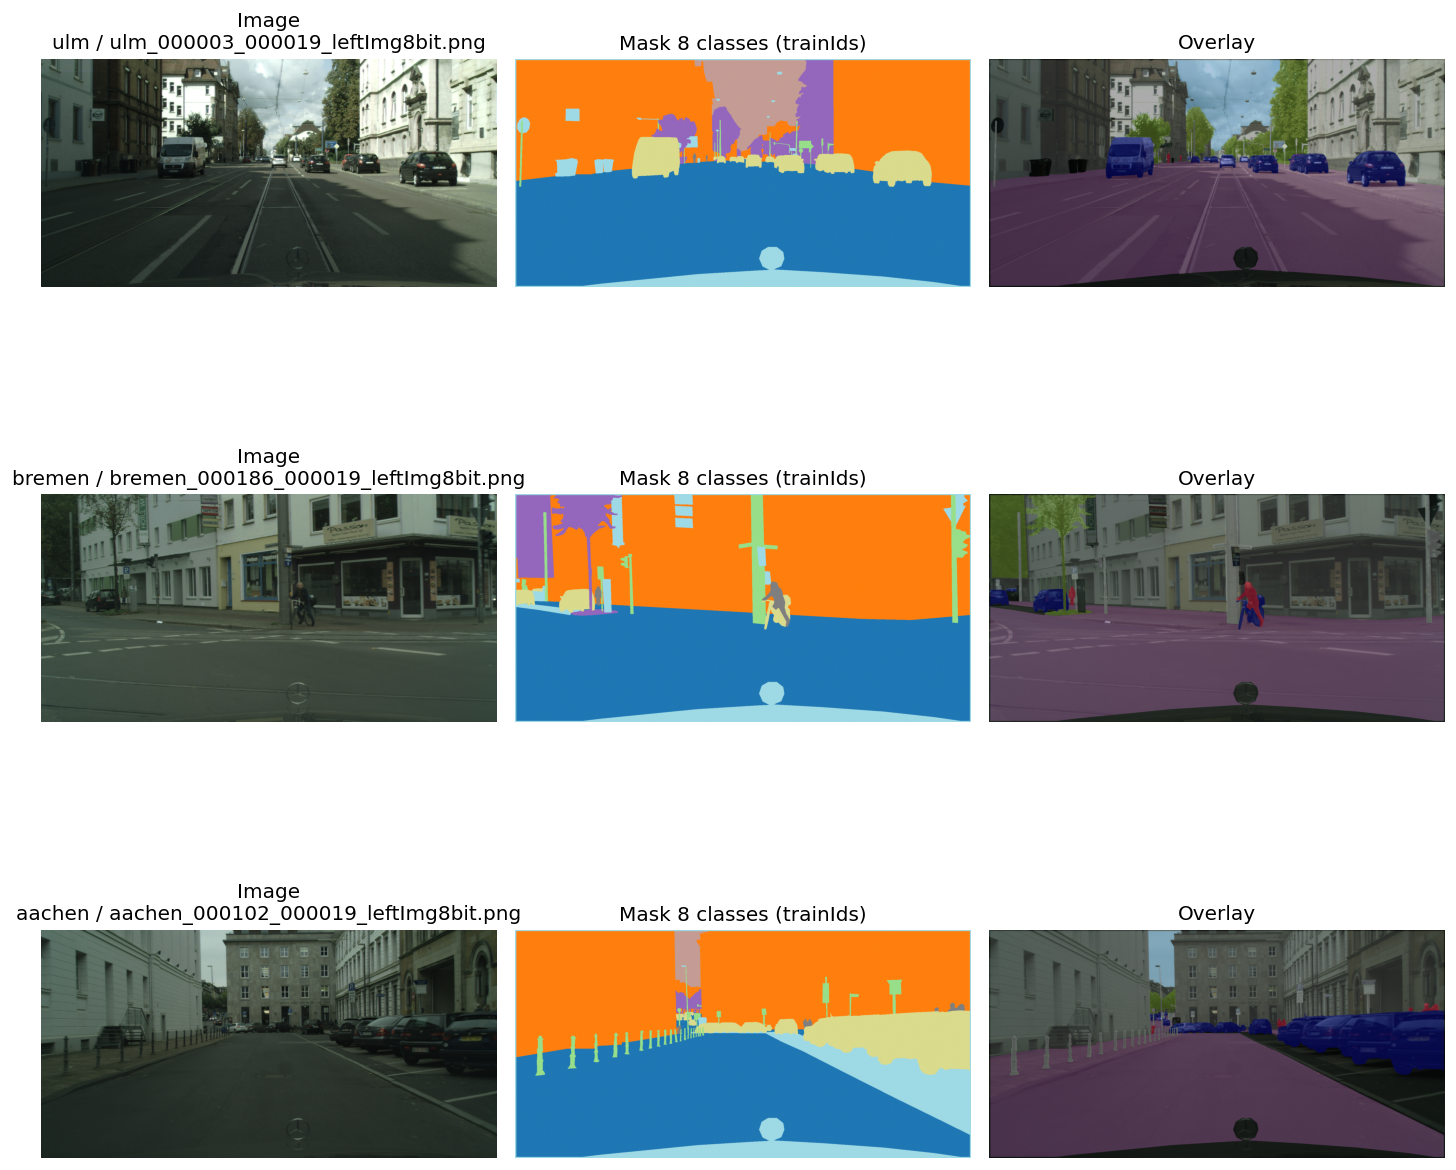

Classes 8c: ['flat', 'construction', 'object', 'nature', 'sky', 'human', 'vehicle', 'void']


In [21]:
# === Explorer des exemples Cityscapes : image, mask 8 classes, overlay ===
from pathlib import Path
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# --- chemins (réutilise IMG_DIR/GT_DIR si déjà définis ; sinon, fixe-les ici)
try:
    IMG_DIR
    GT_DIR
except NameError:
    ROOT_CS = Path("/Users/anasesseddiki/Desktop/Projet8/data")
    IMG_DIR = ROOT_CS / "P8_Cityscapes_leftImg8bit_trainvaltest" / "leftImg8bit"
    GT_DIR  = ROOT_CS / "P8_Cityscapes_gtFine_trainvaltest"      / "gtFine"

SPLIT      = "train"     # "train" | "val"
N_SAMPLES  = 3           # nb d’exemples à afficher
ALPHA      = 0.45        # transparence du mask sur l’overlay

# --- classes 8c + palette ---
CLASS_NAMES_8 = ["flat","construction","object","nature","sky","human","vehicle","void"]
PALETTE_8 = np.array([
    [128,  64, 128],  # flat
    [ 70,  70,  70],  # construction
    [153, 153, 153],  # object
    [107, 142,  35],  # nature
    [ 70, 130, 180],  # sky
    [220,  20,  60],  # human
    [  0,   0, 142],  # vehicle
    [  0,   0,   0],  # void
], dtype=np.uint8)

# --- LUTs ---
# labelId -> trainId (officiel Cityscapes)
LABELID_TO_TRAINID = {
     0:255,  1:255,  2:255,  3:255,  4:255,  5:255,  6:255,
     7:0,    8:1,
     9:255, 10:255,
    11:2,   12:3,   13:4,
    14:255, 15:255, 16:255,
    17:5,   18:255,
    19:6,   20:7,
    21:8,   22:9,   23:10,
    24:11,  25:12,
    26:13,  27:14,  28:15,
    29:255, 30:255,
    31:16,  32:17,  33:18,
    34:255,
}
LUT_L2T = np.full(256, 255, dtype=np.uint8)
for k,v in LABELID_TO_TRAINID.items(): LUT_L2T[k] = v

# trainId -> 8 classes
TRAINID_TO_8 = {
     0:0, 1:0,
     2:1, 3:1, 4:1,
     5:2, 6:2, 7:2,
     8:3, 9:3,
    10:4,
    11:5, 12:5,
    13:6, 14:6, 15:6, 16:6, 17:6, 18:6,
   255:7,
}
LUT_T2_8 = np.full(256, 7, dtype=np.uint8)
for k,v in TRAINID_TO_8.items(): LUT_T2_8[k] = v

# --- helpers ---
def find_mask_for(img_path: Path):
    base = img_path.name.replace("_leftImg8bit.png", "")
    city = img_path.parent.name
    split = img_path.parent.parent.name
    m_train = GT_DIR / split / city / f"{base}_gtFine_trainIds.png"
    m_label = GT_DIR / split / city / f"{base}_gtFine_labelIds.png"
    m_color = GT_DIR / split / city / f"{base}_gtFine_color.png"
    if m_train.exists(): return m_train, "trainIds"
    if m_label.exists(): return m_label, "labelIds"
    if m_color.exists(): return m_color, "color"
    return None, None

def to_8classes(mask_img: Image.Image, kind: str) -> np.ndarray:
    arr = np.array(mask_img)
    if kind == "color":
        # pas d’indice → on garde tel quel pour affichage brut et on met tout en void (rarement utile)
        return np.full(arr.shape[:2], 7, dtype=np.uint8)
    if arr.ndim == 3:  # si jamais
        arr = arr[...,0]
    if kind == "labelIds":
        arr = LUT_L2T[arr]      # -> trainIds
    # kind == "trainIds" maintenant
    return LUT_T2_8[arr]        # -> 0..7

def colorize_8c(mask8: np.ndarray) -> np.ndarray:
    return PALETTE_8[mask8]     # [H,W,3] RGB

def overlay(img_rgb: np.ndarray, mask_rgb: np.ndarray, alpha=0.45) -> np.ndarray:
    img = img_rgb.astype(np.float32) / 255.0
    msk = mask_rgb.astype(np.float32) / 255.0
    return np.clip((1-alpha)*img + alpha*msk, 0, 1)

# --- sélection & affichage ---
all_imgs = sorted((IMG_DIR / SPLIT).rglob("*_leftImg8bit.png"))
assert len(all_imgs) > 0, f"Aucune image trouvée sous {IMG_DIR/SPLIT}"
sample = random.sample(all_imgs, k=min(N_SAMPLES, len(all_imgs)))

fig, axes = plt.subplots(len(sample), 3, figsize=(12, 4*len(sample)))
if len(sample) == 1: axes = np.expand_dims(axes, 0)

for row, img_path in enumerate(sample):
    mask_path, kind = find_mask_for(img_path)
    img = np.array(Image.open(img_path).convert("RGB"))
    axes[row,0].imshow(img); axes[row,0].set_title(f"Image\n{img_path.parent.name} / {img_path.name}"); axes[row,0].axis("off")

    if mask_path is None:
        axes[row,1].text(0.5,0.5,"Mask introuvable", ha="center", va="center"); axes[row,1].axis("off")
        axes[row,2].axis("off")
        continue

    m_img = Image.open(mask_path)
    m8 = to_8classes(m_img, kind)                  # [H,W] 0..7
    m8_rgb = colorize_8c(m8)                       # [H,W,3]
    axes[row,1].imshow(m8, cmap="tab20"); axes[row,1].set_title(f"Mask 8 classes ({kind})"); axes[row,1].axis("off")
    axes[row,2].imshow(overlay(img, m8_rgb, ALPHA)); axes[row,2].set_title("Overlay"); axes[row,2].axis("off")

plt.tight_layout(); plt.show()

print("Classes 8c:", CLASS_NAMES_8)


In [22]:
# === Cityscapes → 8 classes : pipeline tf.data ===
import tensorflow as tf
import numpy as np
from pathlib import Path

# (si besoin) redéfinir IMG_DIR / GT_DIR :
# ROOT_CS = Path("/Users/anasesseddiki/Desktop/Projet8/data")
# IMG_DIR = ROOT_CS / "P8_Cityscapes_leftImg8bit_trainvaltest" / "leftImg8bit"
# GT_DIR  = ROOT_CS / "P8_Cityscapes_gtFine_trainvaltest"      / "gtFine"

# trainId → 8 classes
TRAINID_TO_8 = {
     0:0, 1:0,               # flat
     2:1, 3:1, 4:1,          # construction
     5:2, 6:2, 7:2,          # object
     8:3, 9:3,               # nature
    10:4,                    # sky
    11:5, 12:5,              # human
    13:6, 14:6, 15:6, 16:6, 17:6, 18:6,  # vehicle
   255:7,                    # void
}
LUT_256_TO_8 = np.full(256, 7, dtype=np.uint8)
for k, v in TRAINID_TO_8.items():
    LUT_256_TO_8[k] = v
LUT_256_TO_8_T = tf.constant(LUT_256_TO_8, dtype=tf.uint8)

def list_images(split: str) -> list[Path]:
    return sorted((IMG_DIR / split).rglob("*_leftImg8bit.png"))

def to_mask_path(img_path: Path) -> Path:
    base  = img_path.name.replace("_leftImg8bit.png", "")
    city  = img_path.parent.name
    split = img_path.parent.parent.name
    return GT_DIR / split / city / f"{base}_gtFine_trainIds.png"

def decode_image(path: tf.Tensor, size: tuple[int,int]) -> tf.Tensor:
    x = tf.io.read_file(path)
    x = tf.image.decode_png(x, channels=3)
    x = tf.image.convert_image_dtype(x, tf.float32)  # [0,1]
    if size: x = tf.image.resize(x, size, method="bilinear")
    return x

def decode_mask_8c(path: tf.Tensor, size: tuple[int,int]) -> tf.Tensor:
    x = tf.io.read_file(path)
    x = tf.image.decode_png(x, channels=1)          # uint8 trainIds
    if size: x = tf.image.resize(x, size, method="nearest")
    x = tf.squeeze(x, -1)                           # [H,W]
    x = tf.gather(LUT_256_TO_8_T, tf.cast(x, tf.int32))  # [H,W] in 0..7
    return tf.expand_dims(x, -1)                    # [H,W,1]

def augment(img, msk):
    # flip horizontal
    flip = tf.random.uniform([]) > 0.5
    img  = tf.cond(flip, lambda: tf.image.flip_left_right(img), lambda: img)
    msk  = tf.cond(flip, lambda: tf.image.flip_left_right(msk), lambda: msk)
    # léger jitter
    img  = tf.image.random_brightness(img, 0.05)
    img  = tf.image.random_contrast(img, 0.95, 1.05)
    return tf.clip_by_value(img, 0.0, 1.0), msk

def make_dataset(split: str,
                 img_size=(256, 512),
                 batch_size=4,
                 shuffle=True,
                 augment_data=True) -> tf.data.Dataset:
    img_paths_py = list_images(split)
    msk_paths_py = [to_mask_path(p) for p in img_paths_py]
    pairs = [(str(i), str(m)) for i, m in zip(img_paths_py, msk_paths_py) if m.exists()]
    if not pairs:
        raise RuntimeError(f"Aucun couple image/mask trouvé pour split='{split}'.")
    imgs, msks = zip(*pairs)
    ds = tf.data.Dataset.from_tensor_slices((list(imgs), list(msks)))
    if shuffle:
        ds = ds.shuffle(len(pairs), reshuffle_each_iteration=True)
    def _load(i, m):
        return decode_image(i, img_size), decode_mask_8c(m, img_size)
    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# datasets
IMG_SIZE = (256, 512)
BATCH    = 4
train_ds = make_dataset("train", img_size=IMG_SIZE, batch_size=BATCH, shuffle=True,  augment_data=True)
val_ds   = make_dataset("val",   img_size=IMG_SIZE, batch_size=BATCH, shuffle=False, augment_data=False)


In [23]:
# === UNet-mini (entrée IMG_SIZE, sortie 8 classes) ===
from tensorflow.keras import layers, models

N_CLASSES = 8
INPUT_SHAPE = IMG_SIZE + (3,)

def conv_block(x, f):
    x = layers.Conv2D(f, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(f, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def unet_mini(input_shape=INPUT_SHAPE, base=32, num_classes=N_CLASSES):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = conv_block(inputs, base)       ; p1 = layers.MaxPool2D()(c1)
    c2 = conv_block(p1,    base*2)      ; p2 = layers.MaxPool2D()(c2)
    c3 = conv_block(p2,    base*4)      ; p3 = layers.MaxPool2D()(c3)
    c4 = conv_block(p3,    base*8)      ; p4 = layers.MaxPool2D()(c4)

    # Bottleneck
    bn = conv_block(p4, base*16)

    # Decoder
    u4 = layers.UpSampling2D()(bn)      ; u4 = layers.Concatenate()([u4, c4]); c5 = conv_block(u4, base*8)
    u3 = layers.UpSampling2D()(c5)      ; u3 = layers.Concatenate()([u3, c3]); c6 = conv_block(u3, base*4)
    u2 = layers.UpSampling2D()(c6)      ; u2 = layers.Concatenate()([u2, c2]); c7 = conv_block(u2, base*2)
    u1 = layers.UpSampling2D()(c7)      ; u1 = layers.Concatenate()([u1, c1]); c8 = conv_block(u1, base)

    outputs = layers.Conv2D(num_classes, 1, activation="softmax")(c8)
    return models.Model(inputs, outputs, name="UNetMini_8c")

model = unet_mini()
model.summary()


Model: "UNetMini_8c"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 256, 512,  │          0 │ input_layer[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 512,  │        896 │ cast[0][0]        │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 512,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256, 512,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 512,  │      9,248 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 512,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 256, 512,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 256,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 256,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 256,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 256,  │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 256,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 128,   │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 128,   │     73,856 │ max_pooling2d_1[

 Total params: 7,858,664 (29.98 MB)

 Trainable params: 7,852,776 (29.96 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [25]:
# === Compile & Fit (corrigé pour float16/float32 mix) ===
import tensorflow as tf
from tensorflow.keras import callbacks, optimizers, losses

def dice_soft_macro(y_true, y_pred, eps=1e-6):
    # y_true: [B,H,W,1], ints 0..7 ; y_pred: [B,H,W,8], float16/float32
    y_true = tf.squeeze(tf.cast(y_true, tf.int32), -1)               # [B,H,W]
    y_true = tf.one_hot(y_true, depth=N_CLASSES, dtype=tf.float32)   # [B,H,W,8]
    y_pred = tf.cast(y_pred, tf.float32)                             # 🔧 force même dtype
    y_pred = tf.clip_by_value(y_pred, eps, 1.0)
    inter = tf.reduce_sum(y_true * y_pred, axis=[1,2])               # [B,8]
    den   = tf.reduce_sum(y_true + y_pred, axis=[1,2])               # [B,8]
    dice  = (2.0 * inter + eps) / (den + eps)
    return tf.reduce_mean(dice)

model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=["sparse_categorical_accuracy", dice_soft_macro],
)

ckpt_path = "models/unet_mini_8c.keras"
cbs = [
    callbacks.ModelCheckpoint(ckpt_path, save_best_only=True, monitor="val_dice_soft_macro", mode="max"),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    callbacks.EarlyStopping(monitor="val_dice_soft_macro", mode="max", patience=8, restore_best_weights=True),
]

EPOCHS = 20
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cbs,
)
print("✅ Best model sauvegardé ->", ckpt_path)


Epoch 1/20


2025-11-05 20:48:32.453468: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_soft_macro: 0.3815 - loss: 0.8848 - sparse_categorical_accuracy: 0.7192

2025-11-05 21:06:28.578585: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


744/744 ━━━━━━━━━━━━━━━━━━━━ 1095s 1s/step - dice_soft_macro: 0.3816 - loss: 0.8846 - sparse_categorical_accuracy: 0.7193 - val_dice_soft_macro: 0.4855 - val_loss: 0.6892 - val_sparse_categorical_accuracy: 0.7724 - learning_rate: 0.0010
Epoch 2/20
744/744 ━━━━━━━━━━━━━━━━━━━━ 1188s 2s/step - dice_soft_macro: 0.5271 - loss: 0.4898 - sparse_categorical_accuracy: 0.8445 - val_dice_soft_macro: 0.5334 - val_loss: 0.5214 - val_sparse_categorical_accuracy: 0.8396 - learning_rate: 0.0010
Epoch 3/20
744/744 ━━━━━━━━━━━━━━━━━━━━ 2216s 3s/step - dice_soft_macro: 0.5656 - loss: 0.4292 - sparse_categorical_accuracy: 0.8631 - val_dice_soft_macro: 0.5393 - val_loss: 0.5442 - val_sparse_categorical_accuracy: 0.8350 - learning_rate: 0.0010
Epoch 4/20
744/744 ━━━━━━━━━━━━━━━━━━━━ 1205s 2s/step - dice_soft_macro: 0.5846 - loss: 0.3983 - sparse_categorical_accuracy: 0.8720 - val_dice_soft_macro: 0.5654 - val_loss: 0.4873 - val_sparse_categorical_accuracy: 0.8472 - learning_rate: 0.0010
Epoch 5/20
744/744 

In [26]:
from tensorflow.keras import layers, models, applications

def build_unet_mobilenetv2(input_shape=(256, 512, 3), n_classes=8):
    base_model = applications.MobileNetV2(
        input_shape=input_shape, include_top=False, weights="imagenet"
    )

    # Récupération de certains blocs pour le skip-connection
    skips = [
        base_model.get_layer(name).output
        for name in ["block_1_expand_relu", "block_3_expand_relu",
                     "block_6_expand_relu", "block_13_expand_relu"]
    ]
    x = base_model.output  # sortie du dernier bloc convolutionnel

    # Décodeur type UNet
    for skip in reversed(skips):
        x = layers.Conv2DTranspose(256, 3, strides=2, padding="same")(x)
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)

    # Upsampling final pour revenir à la taille d’entrée
    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2D(n_classes, 1, activation="softmax")(x)

    model = models.Model(inputs=base_model.input, outputs=x)
    return model


# Instanciation
model2 = build_unet_mobilenetv2(input_shape=(256, 512, 3), n_classes=N_CLASSES)
model2.summary()


/var/folders/x1/nfm_4g816d78q82lfzl6j0bh0000gn/T/ipykernel_11968/884637350.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_1 (Cast)       │ (None, 256, 512,  │          0 │ input_layer_1[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 256,  │        864 │ cast_1[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 256,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 256,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 256,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 256,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 256,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 256,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 256,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 256,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 256,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 256,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 257,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 128,   │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 128,   │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 128,   │          0 │ block_1_depthwis

 Total params: 11,960,520 (45.63 MB)

 Trainable params: 11,924,360 (45.49 MB)

 Non-trainable params: 36,160 (141.25 KB)

In [27]:
from tensorflow.keras import callbacks, optimizers, losses

def dice_soft_macro(y_true, y_pred, eps=1e-6):
    y_true = tf.squeeze(tf.cast(y_true, tf.int32), -1)
    y_true = tf.one_hot(y_true, depth=N_CLASSES, dtype=tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, eps, 1.0)
    inter = tf.reduce_sum(y_true * y_pred, axis=[1,2])
    den   = tf.reduce_sum(y_true + y_pred, axis=[1,2])
    dice  = (2.0 * inter + eps) / (den + eps)
    return tf.reduce_mean(dice)

model2.compile(
    optimizer=optimizers.Adam(1e-4),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=["sparse_categorical_accuracy", dice_soft_macro],
)

ckpt_path = "models/unet_mobilenetv2_8c.keras"
cbs = [
    callbacks.ModelCheckpoint(ckpt_path, save_best_only=True, monitor="val_dice_soft_macro", mode="max"),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    callbacks.EarlyStopping(monitor="val_dice_soft_macro", mode="max", patience=8, restore_best_weights=True),
]

EPOCHS = 20
history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cbs,
)
print("✅ Best model sauvegardé ->", ckpt_path)


Epoch 1/20


2025-11-06 07:37:43.821631: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_soft_macro: 0.4704 - loss: 0.6361 - sparse_categorical_accuracy: 0.8016

2025-11-06 07:55:33.811353: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


744/744 ━━━━━━━━━━━━━━━━━━━━ 1128s 1s/step - dice_soft_macro: 0.4705 - loss: 0.6358 - sparse_categorical_accuracy: 0.8017 - val_dice_soft_macro: 0.4927 - val_loss: 0.7290 - val_sparse_categorical_accuracy: 0.7864 - learning_rate: 1.0000e-04
Epoch 2/20
744/744 ━━━━━━━━━━━━━━━━━━━━ 1207s 2s/step - dice_soft_macro: 0.6331 - loss: 0.3197 - sparse_categorical_accuracy: 0.8954 - val_dice_soft_macro: 0.5952 - val_loss: 0.4100 - val_sparse_categorical_accuracy: 0.8632 - learning_rate: 1.0000e-04
Epoch 3/20
744/744 ━━━━━━━━━━━━━━━━━━━━ 1340s 2s/step - dice_soft_macro: 0.6617 - loss: 0.2804 - sparse_categorical_accuracy: 0.9056 - val_dice_soft_macro: 0.6233 - val_loss: 0.3837 - val_sparse_categorical_accuracy: 0.8765 - learning_rate: 1.0000e-04
Epoch 4/20
744/744 ━━━━━━━━━━━━━━━━━━━━ 1254s 2s/step - dice_soft_macro: 0.6771 - loss: 0.2579 - sparse_categorical_accuracy: 0.9116 - val_dice_soft_macro: 0.6389 - val_loss: 0.3414 - val_sparse_categorical_accuracy: 0.8853 - learning_rate: 1.0000e-04
Epo

In [35]:
## <a name="C1">1 - Régression Logistique</a>

2025-11-06 16:53:58.470048: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


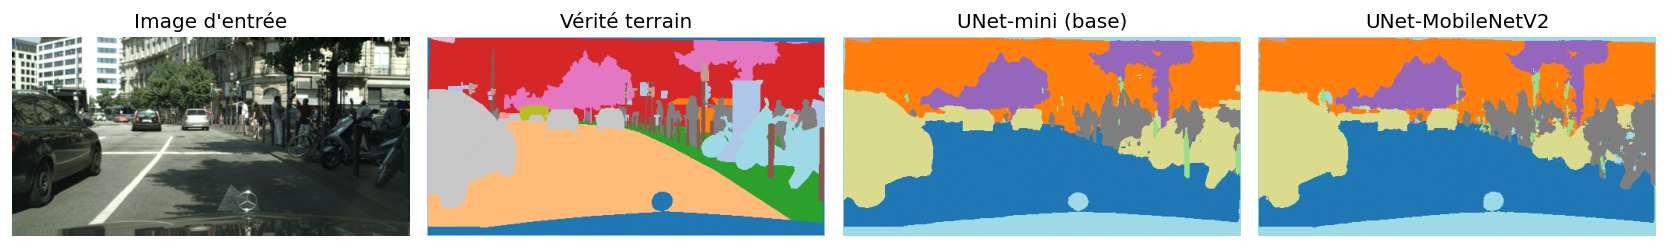

🖼️ Image : /Users/anasesseddiki/Desktop/Projet8/data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit/val/frankfurt/frankfurt_000000_012868_leftImg8bit.png
🧩 Masque : /Users/anasesseddiki/Desktop/Projet8/data/P8_Cityscapes_gtFine_trainvaltest/gtFine/val/frankfurt/frankfurt_000000_012868_gtFine_labelIds.png


In [29]:
import random
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# --- Rechargement des 2 modèles sauvegardés ---
model1_path = "models/unet_mini_8c.keras"
model2_path = "models/unet_mobilenetv2_8c.keras"

model1 = tf.keras.models.load_model(model1_path, custom_objects={"dice_soft_macro": dice_soft_macro})
model2 = tf.keras.models.load_model(model2_path, custom_objects={"dice_soft_macro": dice_soft_macro})

# --- Sélection d'une image aléatoire du jeu de validation ---
sample_imgs = sorted((IMG_DIR / "val").rglob("*_leftImg8bit.png"))
img_path = random.choice(sample_imgs)
base = img_path.name.replace("_leftImg8bit.png", "")
city = img_path.parent.name

mask_path = GT_DIR / "val" / city / f"{base}_gtFine_labelIds.png"

# --- Préparation image ---
# ⚠️ bien passer la taille sous forme (width, height)
img = Image.open(img_path).convert("RGB").resize((IMG_SIZE[1], IMG_SIZE[0]))
mask_true = Image.open(mask_path).resize((IMG_SIZE[1], IMG_SIZE[0]), Image.NEAREST)

img = np.array(img)
mask_true = np.array(mask_true)

# Normalisation
x = img[np.newaxis, ...] / 255.0

# --- Prédictions ---
pred1 = np.argmax(model1.predict(x), axis=-1)[0]
pred2 = np.argmax(model2.predict(x), axis=-1)[0]

# --- Affichage ---
plt.figure(figsize=(14,6))
plt.subplot(1,4,1); plt.imshow(img); plt.title("Image d'entrée"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(mask_true, cmap="tab20"); plt.title("Vérité terrain"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(pred1, cmap="tab20"); plt.title("UNet-mini (base)"); plt.axis("off")
plt.subplot(1,4,4); plt.imshow(pred2, cmap="tab20"); plt.title("UNet-MobileNetV2"); plt.axis("off")

plt.tight_layout()
plt.show()

print("🖼️ Image :", img_path)
print("🧩 Masque :", mask_path)


In [38]:
from tensorflow.keras import layers, models, applications
import tensorflow as tf

N_CLASSES = 8
INPUT_SHAPE = IMG_SIZE + (3,)  # IMG_SIZE=(256,512)

def aspp_static(x, filters=256, rates=(6, 12, 18), target_hw=(16, 32), name="aspp"):
    y = []
    # 1x1
    b0 = layers.Conv2D(filters, 1, padding="same", use_bias=False, name=f"{name}_conv1x1")(x)
    b0 = layers.BatchNormalization(name=f"{name}_bn1x1")(b0); b0 = layers.ReLU()(b0); y.append(b0)
    # 3x3 dilatées
    for r in rates:
        b = layers.SeparableConv2D(filters, 3, padding="same", dilation_rate=r, use_bias=False,
                                   name=f"{name}_sep3x3_r{r}")(x)
        b = layers.BatchNormalization(name=f"{name}_bn_r{r}")(b); b = layers.ReLU()(b); y.append(b)
    # image pooling → 1x1 → resize statique à (H/16, W/16)
    ip = layers.GlobalAveragePooling2D(keepdims=True, name=f"{name}_gap")(x)
    ip = layers.Conv2D(filters, 1, use_bias=False, name=f"{name}_img_conv")(ip)
    ip = layers.BatchNormalization(name=f"{name}_img_bn")(ip); ip = layers.ReLU()(ip)
    ip = layers.Resizing(target_hw[0], target_hw[1], interpolation="bilinear", name=f"{name}_img_resize")(ip)
    y.append(ip)

    y = layers.Concatenate(name=f"{name}_concat")(y)
    y = layers.Conv2D(filters, 1, padding="same", use_bias=False, name=f"{name}_proj")(y)
    y = layers.BatchNormalization(name=f"{name}_proj_bn")(y); y = layers.ReLU()(y)
    y = layers.Dropout(0.1, name=f"{name}_drop")(y)
    return y

def deeplabv3p_mnv2(input_shape=INPUT_SHAPE, n_classes=N_CLASSES, freeze_backbone=True):
    inputs = layers.Input(shape=input_shape)
    base = applications.MobileNetV2(input_shape=input_shape, include_top=False, weights="imagenet")
    if freeze_backbone:
        base.trainable = False

    # feature maps
    low  = base.get_layer("block_3_expand_relu").output    # stride 4
    x    = base.get_layer("block_13_expand_relu").output   # stride 16

    # tailles statiques à OS=16
    h16 = input_shape[0] // 16
    w16 = input_shape[1] // 16

    # ASPP (OS=16) + upsample (x4) pour matcher low (OS=4)
    x = aspp_static(x, filters=256, rates=(6, 12, 18), target_hw=(h16, w16), name="aspp")
    x = layers.UpSampling2D(size=(4, 4), interpolation="bilinear", name="aspp_up4")(x)

    # low-level projection
    low = layers.Conv2D(48, 1, padding="same", use_bias=False, name="low_proj")(low)
    low = layers.BatchNormalization(name="low_bn")(low); low = layers.ReLU()(low)

    # decoder
    x = layers.Concatenate(name="decoder_concat")([x, low])
    x = layers.SeparableConv2D(256, 3, padding="same", use_bias=False, name="dec_sep1")(x)
    x = layers.BatchNormalization(name="dec_bn1")(x); x = layers.ReLU()(x)
    x = layers.SeparableConv2D(256, 3, padding="same", use_bias=False, name="dec_sep2")(x)
    x = layers.BatchNormalization(name="dec_bn2")(x); x = layers.ReLU()(x)

    # upsample final (OS=4 → OS=1)
    x = layers.UpSampling2D(size=(4, 4), interpolation="bilinear", name="final_up4")(x)
    outputs = layers.Conv2D(n_classes, 1, activation="softmax", name="classifier")(x)

    return models.Model(inputs, outputs, name="DeepLabV3Plus_MNV2")

model3 = deeplabv3p_mnv2()
model3.summary()


/var/folders/x1/nfm_4g816d78q82lfzl6j0bh0000gn/T/ipykernel_11968/2434298153.py:32: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = applications.MobileNetV2(input_shape=input_shape, include_top=False, weights="imagenet")


Model: "DeepLabV3Plus_MNV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 256, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_8 (Cast)       │ (None, 256, 512,  │          0 │ input_layer_7[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 256,  │        864 │ cast_8[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 256,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 256,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 256,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 256,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 256,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 256,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 256,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 256,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 256,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 256,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 257,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 128,   │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 128,   │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 128,   │          0 │ block_1_depthwis

 Total params: 1,862,520 (7.10 MB)

 Trainable params: 1,242,072 (4.74 MB)

 Non-trainable params: 620,448 (2.37 MB)

/var/folders/x1/nfm_4g816d78q82lfzl6j0bh0000gn/T/ipykernel_11968/2356696618.py:50: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = applications.MobileNetV2(input_tensor=inputs, include_top=False, weights="imagenet",


2019640/2019640 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Epoch 1/3


2025-11-06 18:16:42.649764: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


150/150 ━━━━━━━━━━━━━━━━━━━━ 62s 375ms/step - dice_soft_macro: 0.2449 - loss: 1.2770 - sparse_categorical_accuracy: 0.5706 - val_dice_soft_macro: 0.1032 - val_loss: 1.9345 - val_sparse_categorical_accuracy: 0.5379
Epoch 2/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 52s 349ms/step - dice_soft_macro: 0.4409 - loss: 0.6332 - sparse_categorical_accuracy: 0.7975 - val_dice_soft_macro: 0.1491 - val_loss: 1.5001 - val_sparse_categorical_accuracy: 0.6360
Epoch 3/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 53s 353ms/step - dice_soft_macro: 0.4766 - loss: 0.5758 - sparse_categorical_accuracy: 0.8103 - val_dice_soft_macro: 0.3171 - val_loss: 0.8123 - val_sparse_categorical_accuracy: 0.7856

📈 Tiny DeepLabV3+ — val metrics:
  - loss=0.8123
  - acc =0.7856
  - dice=0.3171


2025-11-06 18:19:35.206338: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


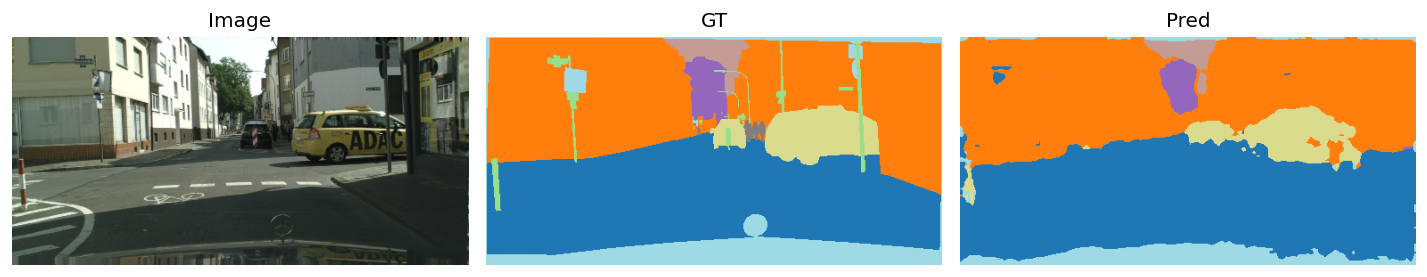

In [40]:
from tensorflow.keras import layers, models, applications, callbacks, optimizers, losses
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Hypers rapides
N_CLASSES   = 8
INPUT_SHAPE = IMG_SIZE + (3,)          # IMG_SIZE défini plus haut (ex: (256,512))
ALPHA       = 0.35                     # MobileNetV2 aminci
FILTERS     = 128                      # Moins de canaux dans l'ASPP/decoder
EPOCHS      = 3                        # Entraînement express
TRAIN_STEPS = 150                      # ≈ 150 batches d'entraînement
VAL_STEPS   = 40                       # ≈ 40 batches de validation

# --- métrique Dice macro robuste au float16 ---
def dice_soft_macro(y_true, y_pred, eps=1e-6):
    y_true = tf.squeeze(tf.cast(y_true, tf.int32), -1)                # [B,H,W]
    y_true = tf.one_hot(y_true, depth=N_CLASSES, dtype=tf.float32)    # [B,H,W,C]
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, eps, 1.0)
    inter  = tf.reduce_sum(y_true * y_pred, axis=[1,2])
    den    = tf.reduce_sum(y_true + y_pred, axis=[1,2])
    dice   = (2.0 * inter + eps) / (den + eps)
    return tf.reduce_mean(dice)

# --- ASPP statique (pas de Lambda dynamique) ---
def aspp_static(x, filters=FILTERS, rates=(6, 12, 18), target_hw=(16, 32), name="aspp"):
    ys = []
    b0 = layers.Conv2D(filters, 1, padding="same", use_bias=False, name=f"{name}_conv1x1")(x)
    b0 = layers.BatchNormalization(name=f"{name}_bn1x1")(b0); b0 = layers.ReLU()(b0); ys.append(b0)
    for r in rates:
        b = layers.SeparableConv2D(filters, 3, padding="same", dilation_rate=r, use_bias=False,
                                   name=f"{name}_sep3x3_r{r}")(x)
        b = layers.BatchNormalization(name=f"{name}_bn_r{r}")(b); b = layers.ReLU()(b); ys.append(b)
    ip = layers.GlobalAveragePooling2D(keepdims=True, name=f"{name}_gap")(x)
    ip = layers.Conv2D(filters, 1, use_bias=False, name=f"{name}_img_conv")(ip)
    ip = layers.BatchNormalization(name=f"{name}_img_bn")(ip); ip = layers.ReLU()(ip)
    ip = layers.Resizing(target_hw[0], target_hw[1], interpolation="bilinear", name=f"{name}_img_resize")(ip)
    ys.append(ip)

    y = layers.Concatenate(name=f"{name}_concat")(ys)
    y = layers.Conv2D(filters, 1, padding="same", use_bias=False, name=f"{name}_proj")(y)
    y = layers.BatchNormalization(name=f"{name}_proj_bn")(y); y = layers.ReLU()(y)
    y = layers.Dropout(0.05, name=f"{name}_drop")(y)
    return y

# --- Modèle tiny ---
def deeplabv3p_mnv2_tiny(input_shape=INPUT_SHAPE, n_classes=N_CLASSES, alpha=ALPHA, filters=FILTERS):
    inputs = layers.Input(shape=input_shape, name="input_tiny")
    base = applications.MobileNetV2(input_tensor=inputs, include_top=False, weights="imagenet",
                                    alpha=alpha, name="mnv2_tiny")
    base.trainable = False  # warm-up tête seule

    low = base.get_layer("block_3_expand_relu").output   # OS=4
    x   = base.get_layer("block_13_expand_relu").output  # OS=16

    h16 = input_shape[0] // 16
    w16 = input_shape[1] // 16
    x = aspp_static(x, filters=filters, rates=(6,12,18), target_hw=(h16, w16), name="aspp")
    x = layers.UpSampling2D(size=(4,4), interpolation="bilinear", name="aspp_up4")(x)

    low = layers.Conv2D( max(24, filters//4), 1, padding="same", use_bias=False, name="low_proj")(low)
    low = layers.BatchNormalization(name="low_bn")(low); low = layers.ReLU()(low)

    x = layers.Concatenate(name="decoder_concat")([x, low])
    x = layers.SeparableConv2D(filters, 3, padding="same", use_bias=False, name="dec_sep1")(x)
    x = layers.BatchNormalization(name="dec_bn1")(x); x = layers.ReLU()(x)
    x = layers.SeparableConv2D(filters, 3, padding="same", use_bias=False, name="dec_sep2")(x)
    x = layers.BatchNormalization(name="dec_bn2")(x); x = layers.ReLU()(x)

    x = layers.UpSampling2D(size=(4,4), interpolation="bilinear", name="final_up4")(x)
    outputs = layers.Conv2D(n_classes, 1, activation="softmax", name="classifier")(x)
    return models.Model(inputs, outputs, name="DeepLabV3Plus_MNV2_Tiny")

model_fast = deeplabv3p_mnv2_tiny()
model_fast.compile(
    optimizer=optimizers.Adam(2e-4),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=["sparse_categorical_accuracy", dice_soft_macro],
)

# Sous-échantillonnage (rapide)
train_ds_fast = train_ds.take(TRAIN_STEPS)
val_ds_fast   = val_ds.take(VAL_STEPS)

cbs = [
    callbacks.EarlyStopping(monitor="val_dice_soft_macro", mode="max", patience=3, restore_best_weights=True),
]

hist_fast = model_fast.fit(
    train_ds_fast,
    validation_data=val_ds_fast,
    epochs=EPOCHS,
    callbacks=cbs,
    verbose=1,
)

# Éval rapide
eval_fast = model_fast.evaluate(val_ds_fast, verbose=0)
print(f"\n📈 Tiny DeepLabV3+ — val metrics:\n  - loss={eval_fast[0]:.4f}"
      f"\n  - acc ={eval_fast[1]:.4f}\n  - dice={eval_fast[2]:.4f}")

# Prédiction-échantillon
for batch in val_ds_fast.take(1):
    x_b, y_b = batch
    break
pred = model_fast.predict(x_b, verbose=0)
pred_cls = np.argmax(pred, axis=-1)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Image"); plt.imshow(x_b[0].numpy()); plt.axis("off")
plt.subplot(1,3,2); plt.title("GT");    plt.imshow(y_b[0].numpy().squeeze(), cmap="tab20"); plt.axis("off")
plt.subplot(1,3,3); plt.title("Pred");  plt.imshow(pred_cls[0], cmap="tab20"); plt.axis("off")
plt.tight_layout(); plt.show()


In [43]:
from pathlib import Path

# 1) Chemin d’export
Path("models").mkdir(exist_ok=True, parents=True)
MODEL_PATH = Path("models/tiny_deeplabv3p_mnv2_8c.keras")

# 2) Sauvegarde (format .keras)
model_fast.save(MODEL_PATH)
print("✅ Sauvegardé :", MODEL_PATH.resolve())


✅ Sauvegardé : /Users/anasesseddiki/Desktop/models/tiny_deeplabv3p_mnv2_8c.keras
